In [19]:
#Imports + GPU Setup
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader

from torchvision import transforms

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

import timm

from tqdm import tqdm


# GPU Setup
device = torch.device("cuda")

print("Using device:", device)
print("GPU Name:", torch.cuda.get_device_name(0))

Using device: cuda
GPU Name: Tesla T4


In [20]:
import os

print(os.listdir("/kaggle/input"))
print(os.listdir("/kaggle/input/datasets"))
print(os.listdir("/kaggle/input/datasets/kmader"))

['datasets']
['kmader']
['skin-cancer-mnist-ham10000']


In [21]:
#Dataset Loading

DATA_DIR = "/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000"
df = pd.read_csv(f"{DATA_DIR}/HAM10000_metadata.csv")

df.head()


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [22]:
#Image Path Mapping
image_dir_1 = f"{DATA_DIR}/HAM10000_images_part_1"
image_dir_2 = f"{DATA_DIR}/HAM10000_images_part_2"

image_paths = {}

for folder in [image_dir_1, image_dir_2]:
    for img in os.listdir(folder):
        image_id = img.split(".")[0]
        image_paths[image_id] = os.path.join(folder, img)

df["image_path"] = df["image_id"].map(image_paths)

In [23]:
#Label Encoding + Splits
label_encoder = LabelEncoder()

df["label"] = label_encoder.fit_transform(df["dx"])

train_df, temp_df = train_test_split(
    df,
    test_size=0.3,
    stratify=df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["label"],
    random_state=42
)

In [24]:
#Transforms

IMG_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [25]:
#Dataset Class

class HAM10000Dataset(Dataset):

    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):

        row = self.dataframe.iloc[idx]

        image = Image.open(row["image_path"]).convert("RGB")

        label = row["label"]

        if self.transform:
            image = self.transform(image)

        return image, label

In [26]:
#Datasets + DataLoaders

train_dataset = HAM10000Dataset(
    train_df,
    transform=train_transform
)

val_dataset = HAM10000Dataset(
    val_df,
    transform=val_test_transform
)

test_dataset = HAM10000Dataset(
    test_df,
    transform=val_test_transform
)

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [27]:
#Load MobileViT

model = timm.create_model(
    "mobilevit_s",
    pretrained=True,
    num_classes=7
)

model = model.to(device)

print("Model loaded successfully")

model.safetensors:   0%|          | 0.00/22.4M [00:00<?, ?B/s]

Model loaded successfully


In [28]:
#Loss Function + Optimizer

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

EPOCHS = 5

In [29]:
#Training Function

def train_one_epoch(model, loader, criterion, optimizer, device):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    loop = tqdm(loader, leave=True)

    for images, labels in loop:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = outputs.max(1)

        total += labels.size(0)

        correct += predicted.eq(labels).sum().item()

        loop.set_postfix(loss=loss.item())

    epoch_loss = running_loss / len(loader)

    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [30]:
#Validation Function

def validate(model, loader, criterion, device):

    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    all_labels = []
    all_preds = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, predicted = outputs.max(1)

            total += labels.size(0)

            correct += predicted.eq(labels).sum().item()

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())

    epoch_loss = running_loss / len(loader)

    epoch_acc = correct / total

    return epoch_loss, epoch_acc, all_labels, all_preds

In [31]:
#Main Training Loop

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

for epoch in range(EPOCHS):

    print(f"\nEpoch [{epoch+1}/{EPOCHS}]")

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc, val_labels, val_preds = validate(
        model,
        val_loader,
        criterion,
        device
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Train Accuracy: {train_acc:.4f}")

    print(f"Validation Loss: {val_loss:.4f}")
    print(f"Validation Accuracy: {val_acc:.4f}")


Epoch [1/5]


100%|██████████| 220/220 [01:12<00:00,  3.05it/s, loss=0.721]


Train Loss: 1.1968
Train Accuracy: 0.6608
Validation Loss: 0.7408
Validation Accuracy: 0.7583

Epoch [2/5]


100%|██████████| 220/220 [00:57<00:00,  3.86it/s, loss=0.532]


Train Loss: 0.6957
Train Accuracy: 0.7616
Validation Loss: 0.6417
Validation Accuracy: 0.8036

Epoch [3/5]


...

Train Loss: 0.5868
Train Accuracy: 0.7969
Validation Loss: 0.5071
Validation Accuracy: 0.8322

Epoch [4/5]


100%|██████████| 220/220 [01:04<00:00,  3.43it/s, loss=2.16] 


Train Loss: 0.5118
Train Accuracy: 0.8235
Validation Loss: 0.4991
Validation Accuracy: 0.8322

Epoch [5/5]


100%|██████████| 220/220 [01:05<00:00,  3.33it/s, loss=2.26] 


Train Loss: 0.4537
Train Accuracy: 0.8462
Validation Loss: 0.4675
Validation Accuracy: 0.8429


In [32]:
test_loss, test_acc, test_labels, test_preds = validate(
    model,
    test_loader,
    criterion,
    device
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Test Loss: 0.4871
Test Accuracy: 0.8377


In [33]:
class_names = label_encoder.classes_

print(classification_report(
    test_labels,
    test_preds,
    target_names=class_names
))

              precision    recall  f1-score   support

       akiec       0.58      0.51      0.54        49
         bcc       0.78      0.64      0.70        77
         bkl       0.64      0.75      0.69       165
          df       0.67      0.24      0.35        17
         mel       0.87      0.37      0.51       167
          nv       0.89      0.97      0.93      1006
        vasc       0.75      0.82      0.78        22

    accuracy                           0.84      1503
   macro avg       0.74      0.61      0.64      1503
weighted avg       0.84      0.84      0.82      1503



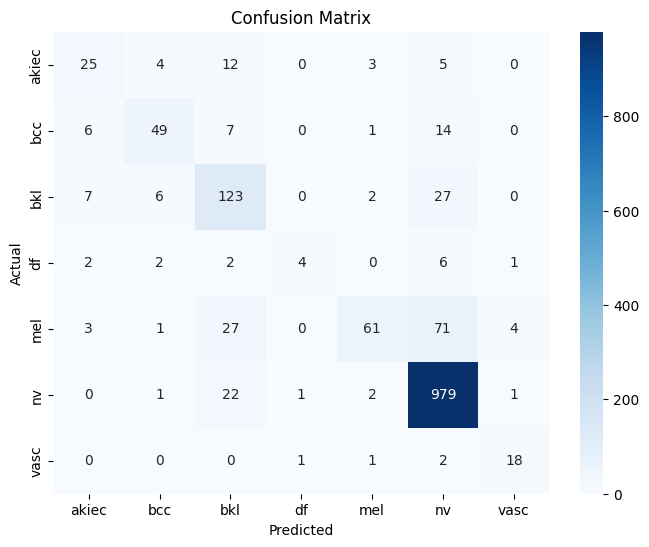

In [38]:
cm = confusion_matrix(test_labels, test_preds)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [35]:
plt.savefig("baseline_confusion_matrix.png")

<Figure size 640x480 with 0 Axes>

In [40]:
report = classification_report(
    test_labels,
    test_preds,
    target_names=class_names
)

with open("baseline_classification_report.txt", "w") as f:
    f.write(report)